# Description 

This notebook provides visual, analysis, and suggestions from the dataset.

There are two parts:

    1. Data-Cleaning 
    2. Data Analysis / Visualization 
    
Final insights will be provided in README.md

In [99]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3
from pathlib import Path 

%matplotlib inline

PROJECT_ROOT = Path.cwd().parent

DATA = 'churn.db'

conn = sqlite3.connect(DATA)


query =  """
SELECT * 

FROM customer_churn_raw
"""

df = pd.read_sql(query, conn)

In [100]:
df.columns.unique()

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

## Data Cleaning 

In [101]:
# Standardise the texts 

obj_cols = df.select_dtypes('object').columns

df[obj_cols] = (
    df[obj_cols].apply(lambda col: col.str.strip().str.lower())
)

In [102]:
# Standardise the Binary columns 

bin_col = [col for col in df.columns if df[col].isin(['Yes', 'No', 'yes', 'no']).all()]

df[bin_col] = df[bin_col].replace({
    'yes':'Yes',
    'no':'No'
})

In [103]:
# Removing columns that does not hold much useful information

col_remove = ['Count', 'Lat Long', 'CustomerID']
df.drop(columns=col_remove, inplace=True)

In [104]:
# Checking for NaN 

df.isna().sum()

Country                 0
State                   0
City                    0
Zip Code                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

There are 5174 NaN values in Churn Reason, the remaining reasons will be investigated

# Data Analysis 

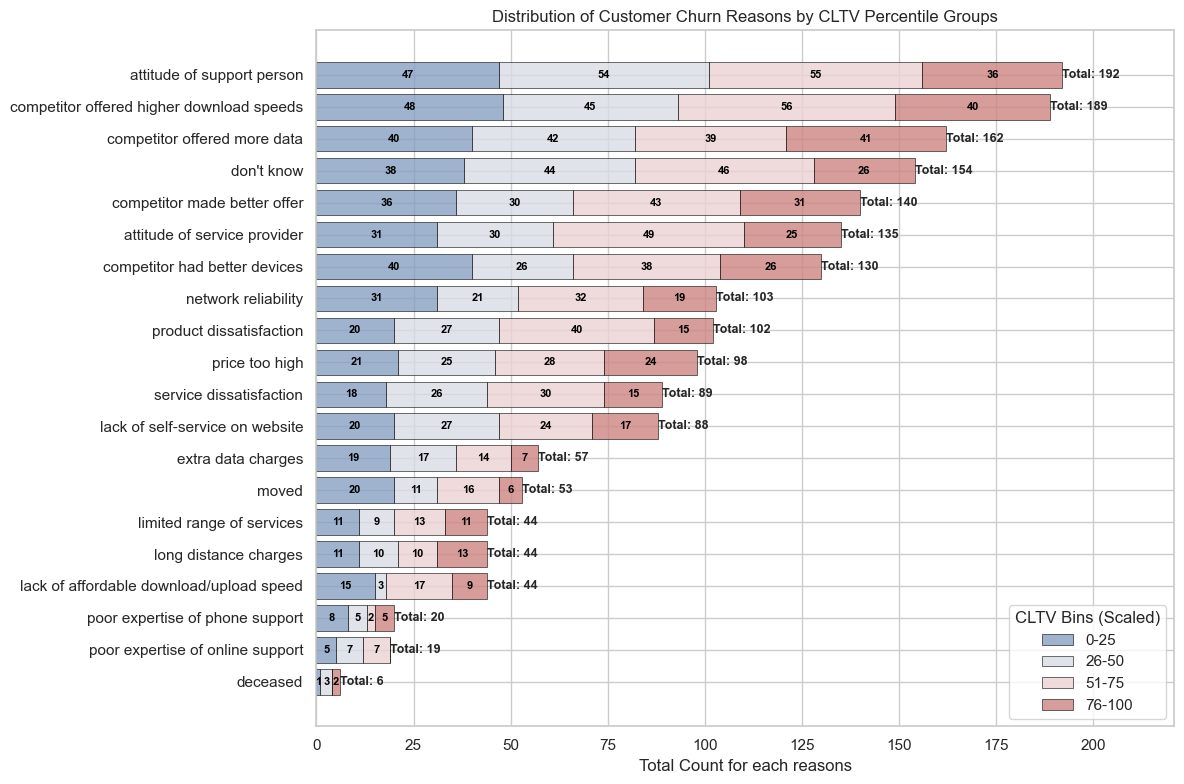

In [105]:
# ------------------ Churn Reasons Analysis -----------------------
churn_reasons = df['Churn Reason'].value_counts().index
counts = df['Churn Reason'].value_counts()

bins = [0, 25, 50, 75, 100]
lab = ['0-25', '26-50', '51-75', '76-100']

# Scaling 
df['CLTV_Scaled'] = 100 * (df['CLTV'] - df['CLTV'].min()) / (df['CLTV'].max() - df['CLTV'].min())

# Bin the dataframe
df['CLTV_BINNED_count'] = pd.cut(df['CLTV_Scaled'], bins=bins, labels=lab, include_lowest=True)
cltv_counts = df['CLTV_BINNED_count'].value_counts().reindex(lab)

# Getting Proportions for each CLTV Groups for each churn reasons 
df_graph = pd.DataFrame(index=churn_reasons, columns=lab + ['Count'])


i = 0
for reason in churn_reasons:
    cur_df = df[df['Churn Reason'] == reason]
    cltv_counts = cur_df['CLTV_BINNED_count'].value_counts().reindex(lab)
    total = len(cur_df)
    for i in range(len(cltv_counts)):
        df_graph.loc[reason, cltv_counts.index[i]] = cltv_counts.values[i]

    
    df_graph.loc[reason, 'Count'] = counts.loc[reason]
        

df_graph = df_graph.astype(int)
df_graph = df_graph.reset_index().rename(columns={'index': 'Churn Reason'})

sns.set_theme(style="whitegrid")

# Sort data
df_graph = df_graph.sort_values('Count', ascending=False)
y_pos = np.arange(len(df_graph))

# Plot with transparency to see all segments
bottom = np.zeros(len(df_graph))
colors = sns.color_palette("vlag", len(lab))

fig, ax = plt.subplots(figsize=(12, 8))

for i, label in enumerate(lab):
    values = df_graph[label].values
    
    ax.barh(y_pos, values, left=bottom, 
            color=colors[i], alpha=0.8, label=label,
            edgecolor='black', linewidth=0.5, height=0.8)
    bottom += values

# Add value labels on each segment
for i, y in enumerate(y_pos):
    current_left = 0
    for j, label in enumerate(lab):
        value = df_graph.iloc[i][label]
        if value > 0:  
            ax.text(current_left + value/2, y, 
                   f'{value:.0f}', 
                   va='center', ha='center',
                   color='black', fontweight='bold', fontsize=8)
        current_left += value

# Add Total value at the end of each bar
for i, (y, total) in enumerate(zip(y_pos, df_graph['Count'].values)):
    ax.text(total, y, f'Total: {total:.0f}', 
            va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_graph['Churn Reason'])
ax.invert_yaxis()
ax.set_xlim(0, df_graph['Count'].max() * 1.15)
ax.set_xlabel('Total Count for each reasons')
ax.set_title('Distribution of Customer Churn Reasons by CLTV Percentile Groups')
ax.legend(loc='lower right', title='CLTV Bins (Scaled)')

plt.tight_layout()
plt.show()



### Overall insights: 

It appears that the primary factor of customer churning is due to the competitor pressure, they  offered better services, more attractive deals, faster speeds, or greater data allowances. 

In addition, service quality and customer experience are significant contributors to churn. A noticeable number of customers cited poor support attitudes, lack of professionalism, and unsatisfactory service interactions as reasons for leaving.

### Insights for high CLTV customers: 

For customers with high CLTV Score, their primary reason to churn is: 

    1. Competitor offered more data
    2. Competitor offered higher download speeds 
    3. attitude of support person
    
This suggests that high-value customers care more about service quality and experience, performance and value relative to competitors. They are willing to change to different providers if the above requirements meet their standard. To retent these customers, overall upgrade to the performance, service attitude and good offers should be considered. 
  

    
### Strategic Recommendations: 

##### 1. Upgrade Core Service Performance
    
   Enhance overall network performance, particularly internet speed and reliability. Improving internet quality would also positively impact related services such as streaming TV and streaming movies.

##### 2. Strengthen Competitive Offerings
    
Introduce more attractive data plans, reduce charges for excess data usage, and periodically benchmark pricing and features against key competitors to remain competitive in the market.
   
##### 3. Improve Customer Service Quality

Provide structured training programs for customer support staff to improve professionalism, communication skills, and service responsiveness. Reducing complaints related to staff attitude will directly improve customer satisfaction and retention. 


In [144]:
# Services that churned customers had 

services = ['Phone Service', 'Multiple Lines', 'Internet Service',        
'Online Security',
'Online Backup',
'Device Protection',
'Tech Support',
'Streaming TV',
'Streaming Movies']

df_churned_services = df[df['Churn Value'] == 1][services].copy()

for col in services:
    df_churned_services[col] = df_churned_services[col].replace('yes', 'Yes')
    df_churned_services[col] = df_churned_services[col].replace('no', 'No')

# Internet service needed to be plotted separetely 
for service in services:
    print(service, df_churned_services[service].unique())

Phone Service ['Yes' 'No']
Multiple Lines ['No' 'Yes' 'no phone service']
Internet Service ['dsl' 'fiber optic' 'No']
Online Security ['Yes' 'No' 'no internet service']
Online Backup ['Yes' 'No' 'no internet service']
Device Protection ['No' 'Yes' 'no internet service']
Tech Support ['No' 'Yes' 'no internet service']
Streaming TV ['No' 'Yes' 'no internet service']
Streaming Movies ['No' 'Yes' 'no internet service']


In [185]:

df_service_counts = pd.DataFrame()

for service in services:
    counts = df_churned_services[service].value_counts().reset_index()
    counts.columns = ['Value', 'Count']
    counts['Service'] = service

    pivot = counts.pivot(index='Service', columns='Value', values='Count').reset_index()
    
    df_service_counts = pd.concat([df_service_counts, pivot], ignore_index=True)

# Fill NaN with 0
df_service_counts = df_service_counts.fillna(0)
df_service_counts = df_service_counts.drop(index=[2]).reset_index().drop(columns='index')
df_service_counts

Value,Service,No,Yes,no phone service,dsl,fiber optic,no internet service
0,Phone Service,170,1699.0,0.0,0.0,0.0,0.0
1,Multiple Lines,849,850.0,170.0,0.0,0.0,0.0
2,Online Security,1461,295.0,0.0,0.0,0.0,113.0
3,Online Backup,1233,523.0,0.0,0.0,0.0,113.0
4,Device Protection,1211,545.0,0.0,0.0,0.0,113.0
5,Tech Support,1446,310.0,0.0,0.0,0.0,113.0
6,Streaming TV,942,814.0,0.0,0.0,0.0,113.0
7,Streaming Movies,938,818.0,0.0,0.0,0.0,113.0


In [254]:

df_internet = df_churned_services['Internet Service'].value_counts()
df_internet = pd.DataFrame(df_internet).reset_index()

df_internet

,Internet Service,count
0,fiber optic,1297
1,dsl,459
2,No,113


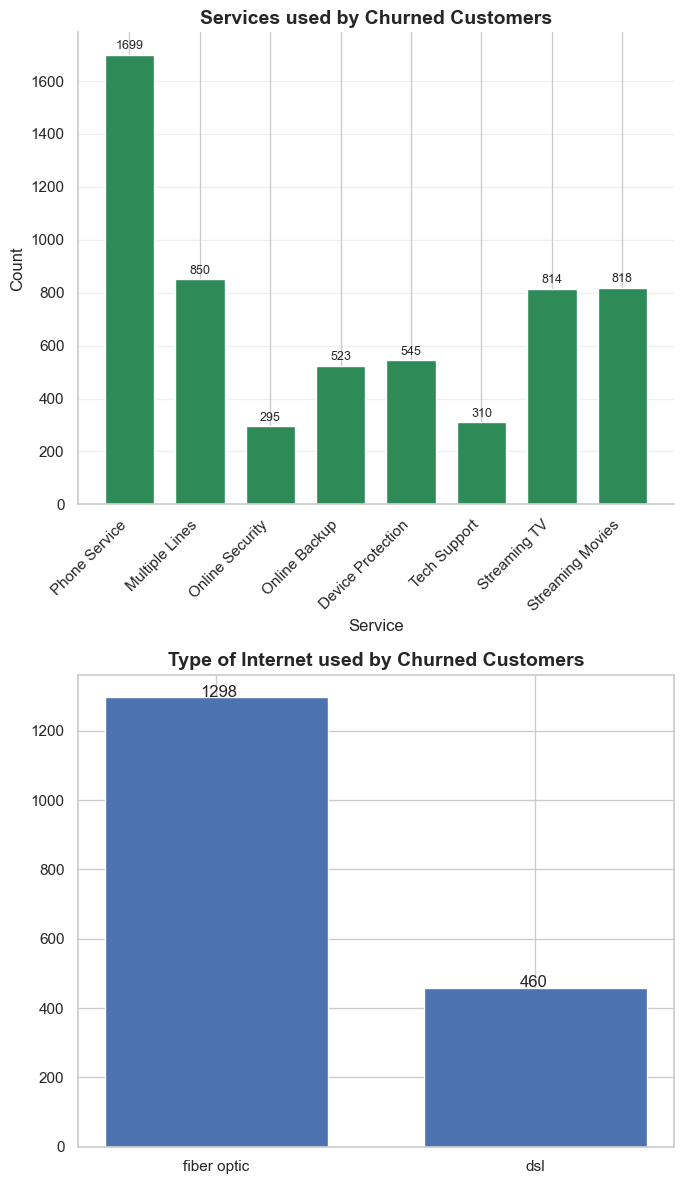

In [255]:
import numpy as np
import matplotlib.pyplot as plt


fig, ax = plt.subplots(2, 1, figsize=(7, 12))

services = df_service_counts['Service'].values
x = np.arange(len(services)) 
width = 0.7  

ax[0].bar(x, df_service_counts['Yes'], width, label='Yes', color='#2E8B57')


ax[0].set_xlabel('Service', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Services used by Churned Customers', fontsize=14, fontweight='bold')
ax[0].set_xticks(x)
ax[0].set_xticklabels(services, rotation=45, ha='right')
ax[0].grid(axis='y', alpha=0.3)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)


for i, (no_val, yes_val) in enumerate(zip(df_service_counts['No'], df_service_counts['Yes'])):
    ax[0].text(i, yes_val + 10, int(yes_val), ha='center', va='bottom', fontsize=9)

ax[1].bar(df_internet['Internet Service'].drop(index=2), df_internet['count'].drop(index=2), 0.7)
ax[1].set_title('Type of Internet used by Churned Customers', fontsize=14, fontweight='bold')
ax[1].text(-0.05, df_internet['count'][0] + 1, df_internet['count'][0] + 1)
ax[1].text(0.95, df_internet['count'][1] + 1, df_internet['count'][1] + 1)

plt.tight_layout()
plt.show()

## Insights 

**1. Phone Service**
For those who churned, the most used service is Phone Service. This confirms the findings from previous part, that competitor offered better deals, such as more data for a given plan or in general better offer which attracts them to move. 

**2. Streaming & Internet Services**
The second most popular service were the streaming & Internet service. 

Fiber optic is the preferred choice for most customers due to its faster speed. Therefore, if a significant number of customers are leaving because of fiber optic speed issues, upgrading network performance must be the company's primary focus

- Streaming services (TV and Movies) can be related to internet service if a customer chose both services.
- This means that if internet service quality is low, it would also impact Streaming services, and therefore result in much higher chance of customers churning.

In [209]:
# The Areas that customers churned the most 
import plotly.express as px
import json
from urllib.request import urlopen


if 'Latitude' in df.columns and 'Longitude' in df.columns:
    df_churn = df[df['Churn Value'] == 1].copy()
    df_zip = df_churn.groupby('Zip Code').agg({
        'Churn Value': 'count',
        'Latitude': 'first',  
        'Longitude': 'first'   
    }).reset_index()
    
    fig = px.scatter_mapbox(
        df_zip,
        lat="Latitude",
        lon="Longitude",
        color="Churn Value",
        zoom=5,
        mapbox_style="carto-positron",
        title="Churn Locations by ZIP Code"
    )
    fig.show()

The data indicates a concentration of customer churn in San Francisco, Los Angeles, and San Diego, suggesting that the emergence of competitors in these key urban markets is a significant factor

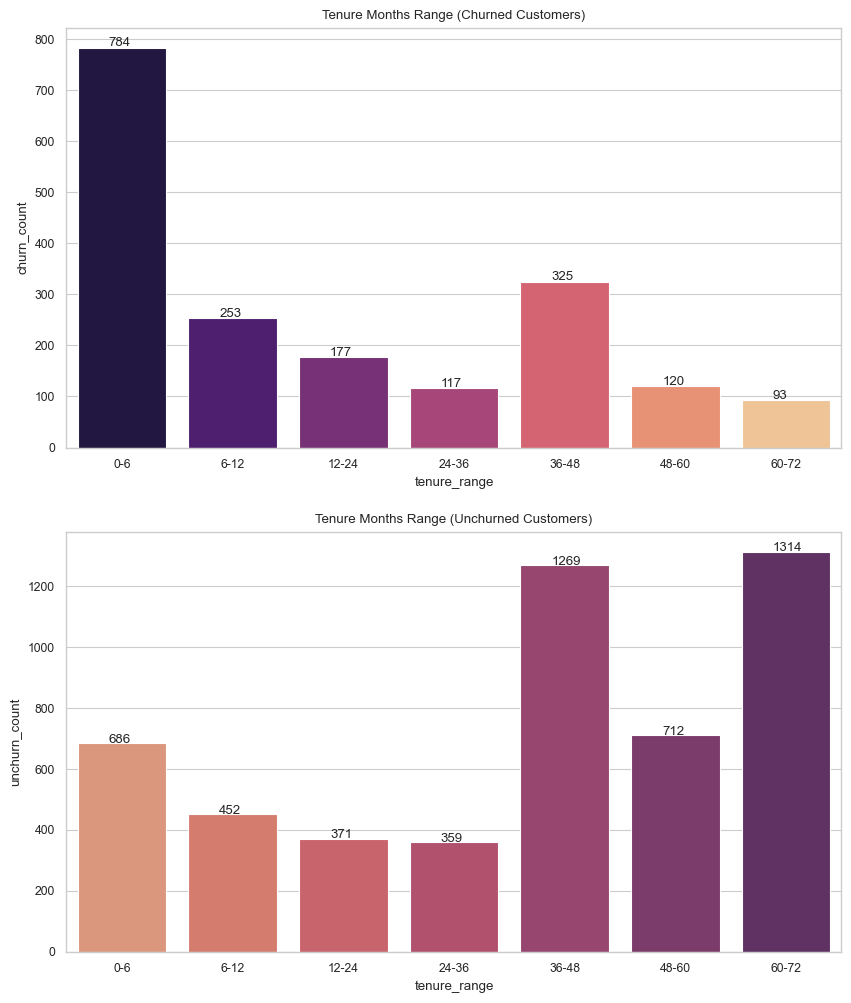

In [87]:
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("RdYlGn_r")

binn = [0, 6, 12, 18, 24, 48, 60, 72]
labels = ['0-6', '6-12', '12-24', '24-36', '36-48','48-60', '60-72']

df_churn = df[df['Churn Value'] == 1].copy()
df_unchurn = df[df['Churn Value'] == 0].copy()

df_churn['tenure_range'] = pd.cut(x=df['Tenure Months'], bins=binn, labels=labels)
df_unchurn['tenure_range'] = pd.cut(x=df['Tenure Months'], bins=binn, labels=labels)

df_churn_grouped = df_churn.groupby('tenure_range').size().reset_index(name='churn_count')
df_unchurn_grouped = df_unchurn.groupby('tenure_range').size().reset_index(name='unchurn_count')

fig, ax = plt.subplots(2, 1, figsize=(10, 12))


# Plot 1: Churned 
sns.barplot(
    data=df_churn_grouped,
    x='tenure_range', 
    y='churn_count',
    ax=ax[0],
    palette='', 
)
ax[0].set_title('Tenure Months Range (Churned Customers)')
for i, v in enumerate(df_churn_grouped['churn_count']):
    ax[0].text(i - 0.12, v + 3, str(v))

    
# Plot 2: Unchurned 
sns.barplot(
    data=df_unchurn_grouped,
    x='tenure_range', 
    y='unchurn_count',
    ax=ax[1],
    palette='flare', 
)
ax[1].set_title('Tenure Months Range (Unchurned Customers)')
for i, v in enumerate(df_unchurn_grouped['unchurn_count']):
    ax[1].text(i - 0.12, v + 1, str(v))

# Insights: 

## Customer Profile: Churned Customers: 
Customer Tenure & Churn Patterns

**1. New Customers (< 6 months)**

Finding: Highest churn concentration in first 6 months

Suggestion: Enhance onboarding experience with targeted offers and proactive engagement to improve early retention

**2. Established Customers (> 48 months)**

Finding: Churn among long-term customers indicates potential service quality issues

Suggestion: Implement loyalty rewards, conduct feedback sessions, and prioritize service improvements to retain valuable long-term relationships

## Customer Profile: Those Who Stay
The majority of retained customers have a tenure exceeding 36 months, indicating that customer loyalty strengthens over time. These long-standing customers represent the company's most valuable asset.

To maintain and strengthen relationships with these loyal customers, we recommend:

- **Strengthen Customer Relationships:** Develop personalized engagement strategies that make customers feel valued and understood, moving beyond transactional interactions to build emotional connections with the brand.


- **Implement a Loyalty Rewards Program:** Introduce tiered rewards that acknowledge and appreciate long-term commitment, offering exclusive benefits, discounts, or early access to new features/services.


- **Establish Continuous Feedback Loops:** Proactively seek customer input through regular surveys, feedback sessions, and advisory panels. Demonstrate that their opinions shape business decisions and service improvements.


- **Create a "Voice of Customer" Program:** Formally integrate customer feedback into product development and service enhancement cycles, showing customers that their insights drive meaningful change

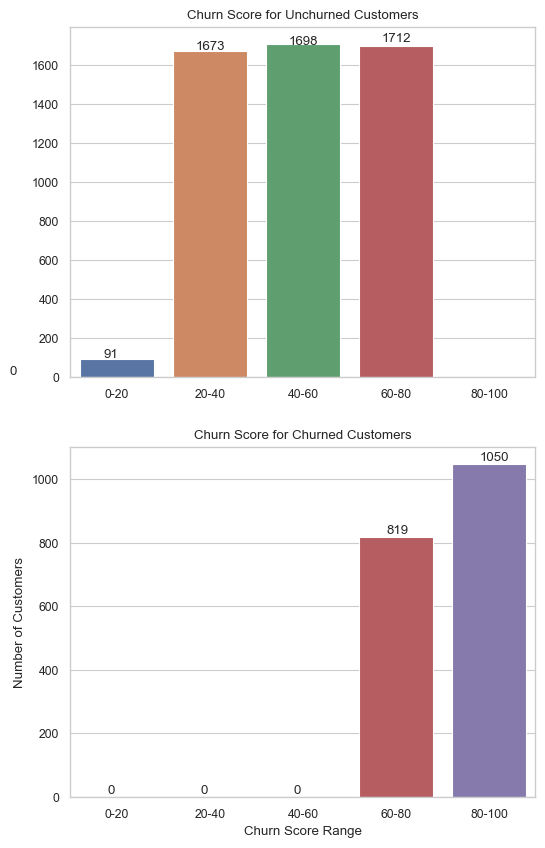

In [309]:
# Churn Score analysis for unchurned customers, what is the trend compared to churned ? 
df_unchurned = df[df['Churn Value'] == 0].copy()
df_churned = df[df['Churn Value'] == 1].copy()


binn = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100']

df_unchurned['Churn_Scored_BIN'] = pd.cut(df_unchurned['Churn Score'], bins=binn, labels=labels)
df_churned['Churn_Scored_BIN'] = pd.cut(df_churned['Churn Score'], bins=binn, labels=labels)

df_unchurn_grouped = df_unchurned['Churn_Scored_BIN'].value_counts()
df_churn_grouped = df_churned['Churn_Scored_BIN'].value_counts()

fig, ax =plt.subplots(2, 1, figsize=(6, 10))

sns.set_style("whitegrid")
sns.set_context("paper")

# Plot 1: Unchurn
sns.barplot(x=df_unchurn_grouped.index, y=df_unchurn_grouped.values, ax=ax[0])
ax[0].set_title('Churn Score for Unchurned Customers')
ax[0].set_xlabel('')
ax[1].set_ylabel('Number of Customers')
for i, v in enumerate(sorted(df_unchurn_grouped.values)):
    ax[0].text(i-1.15, v + 10, str(v))
    
    
# Plot 2: Churned 
sns.barplot(x=df_churn_grouped.index, y=df_churn_grouped.values, ax=ax[1])
ax[1].set_title('Churn Score for Churned Customers');
ax[1].set_xlabel('Churn Score Range')
ax[1].set_ylabel('Number of Customers')
for i, v in enumerate(sorted(df_churn_grouped.values)):
    ax[1].text(i - 0.1, v + 10, str(v))


## Insights 

**1. Churned Customers** 
 Analysis confirms that all churned customers had a churn score between 60 and 100. With zero churned customers falling below this threshold, a score of 60 or higher should be classified as 'High Risk'. 

**2. Unchurned Customers** 
 Critically, 1,712 currently active customers also fall within the 60–80 churn score range. This group requires immediate monitoring and targeted intervention to prevent future churn.
